<h1>K-means Clustering </h1>

More often than not, data will not be labelled - finding patterns in unlabelled data is a common theme in many ML applications. This is done using unupservised ML algorithms. 

***Clustering*** is the most common unsupervised ML technique. It find structure in unlabeled data by indentifying similar groups. Examples include:

- Recommendation Engines
- Search Engines
- Market Segmentation
- Image Segmentation
- Text Segmentation

The aim of clustering is to put data similar to one another in the same group as eachother. 

k refers to the number of clusters we expect to find in the dataset 
means refers to the average distance of data to each cluster centre, which is minimised. 

K-Means clustering is an interative method:
 - Place k random centroids for the inital clusters 
 - Assign data samples to the nearest centroid 
 - Calculate new centroids based on the above assigned data-points
 - Repeat steps 2 and 3 until convergence

Once clusters have been defined unlabelled data points can be assigned to a cluster - this is inference.


In [4]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

iris = datasets.load_iris()


df = pd.DataFrame(iris.data, columns=iris.feature_names)

# The class labels - these are for the sake of training. Will not be present in real world datasets 
df_species = df.copy()
df_species['species'] = iris.target
print(df)

# Inspecting one row of the iris dataset and it's classification
print("Iris classification row 1:", iris.data[0,:], iris.target[0])

# Description
print(iris.DESCR)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
Iris classification row 1: [5.1 3.5 1.4 

Each characteristic in the iris dataset we are interested in is a feature. The features of this dataset are:

- Column 0 - Sepal length 
- Column 1 - Sepal width 
- Column 2 - Petal length 
- Column 3 - Petal width

Visualisation of the dataset:

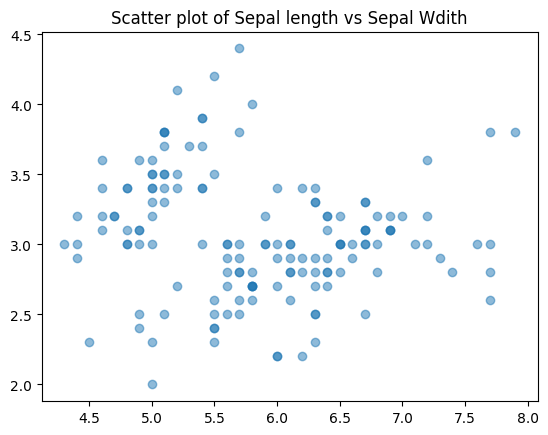

<Figure size 640x480 with 0 Axes>

In [5]:
samples = iris.data 
# Consider only the first two columns 
x = samples[:,0] # all sepal length 
y = samples[:,1] # all sepal wifth
sepal_length_width = np.array(list(zip(x,y)))
# Plot x and y
plt.scatter(x,y, alpha=0.5)
plt.title("Scatter plot of Sepal length vs Sepal Wdith")
plt.show()
plt.clf()

For reference there are 3 species of the iris plant - since this is already known I will choose k=3. In real world this will not be the case. 

[[4.82759317 2.83857845]
 [5.816972   2.62683394]
 [5.10587405 4.25846661]]


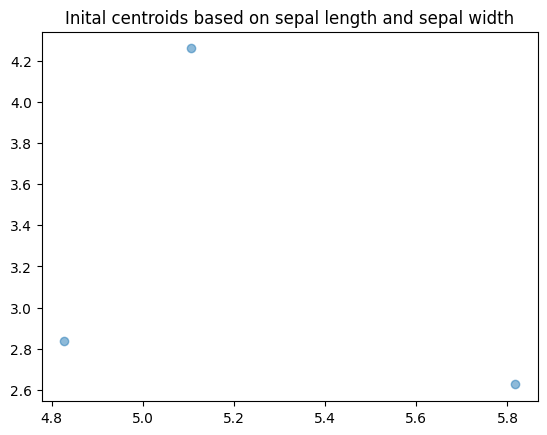

<Figure size 640x480 with 0 Axes>

In [6]:
# Initial value of k
k=3
# Create random list for x that have k random values between min(x) and max(x)
centroids_x = np.random.uniform(min(x), max(x), k)
# Create random list for y that have k random values between min(y) and max(y)
centroids_y = np.random.uniform(min(y), max(y), k)

# The above coordinates for x and y initialise the centroids for x and y
centroids = np.array(list(zip(centroids_x, centroids_y)))
print(centroids)

plt.scatter(centroids_x, centroids_y, alpha=0.5)
plt.title("Inital centroids based on sepal length and sepal width")
plt.show()
plt.clf()

Given the three random points, data will now be assigned to the points closest to them. NOTE: only 2 dimensions of the data have been considered thus far.

In [7]:
def distance(a,b):
    distance = np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
    return distance

labels = np.zeros(len(samples))

In [8]:
def assign_to_centroid(sample, centroids):
    distances = []
    for i in range(len(centroids)):
        distances.append(distance(sample, centroids[i]))
    closest_centroid = np.argmin(distances)
    return closest_centroid

# Assign the nearest centroid to each sample
for i in range(len(samples)):
    labels[i] = assign_to_centroid(samples[i], centroids)
print(labels)
    


[0. 0. 0. 0. 2. 2. 0. 0. 0. 0. 2. 0. 0. 0. 2. 2. 2. 0. 2. 2. 0. 2. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 0. 0. 2. 2. 0. 0. 0. 0. 0. 0. 2. 0. 2. 0.
 2. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [9]:
# Store old centroids
centroids_old = deepcopy(centroids)

# Obtain all datapoints that have a cluster point i
for i in range(k):
    points = []
    for j in range(len(sepal_length_width)):
        if labels[j] == i:
            points.append(sepal_length_width[j])
    # Update position of the centroid to the mean 
    centroids[i] = np.mean(points, axis=0)

print("Old centroids", centroids_old)
print("New centroids", centroids)


Old centroids [[4.82759317 2.83857845]
 [5.816972   2.62683394]
 [5.10587405 4.25846661]]
New centroids [[4.88       3.1075    ]
 [6.34148936 2.90212766]
 [5.325      3.84375   ]]


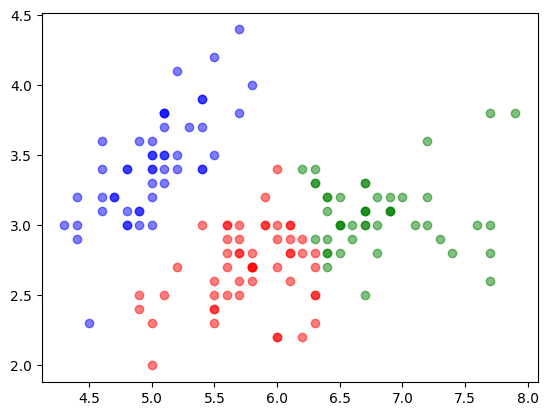

In [10]:
# To store the value of centroids when it updates
centroids_old = np.zeros(centroids.shape)

# Cluster labeles (either 0, 1, or 2)
labels = np.zeros(len(samples))

# Initialise error:
error = np.ones(len(centroids))

while np.any(error!= 0):
  
  # Assign each sample with a label to the nearest centroid
  for i in range(len(samples)):
    distances = []
    for j in range(len(centroids)):
        distances.append(distance(sepal_length_width[i], centroids[j]))
    labels[i] = np.argmin(distances)

# Update centroids
  centroids_old = deepcopy(centroids)

  for i in range(len(centroids)):
    points = []
    for j in range(len(sepal_length_width)):
        if labels[j] == i:
            points.append(sepal_length_width[j])
    # Update position of the centroid to the mean 
    centroids[i] = np.mean(points, axis=0)

  # Compute error
  for i in range(len(centroids)):
     error[i] = distance(centroids[i], centroids_old[i])


colours = ['r', 'g', 'b']

for i in range(len(centroids)):
  points = []
  for j in range(len(sepal_length_width)):
      if labels[j] == i:
          points.append(sepal_length_width[j])
  points = np.array(points)
  plt.scatter(points[:, 0], points[:, 1], c=colours[i], alpha=0.5)



<h1>K-Means Clustering using Scikit-learn</h1>

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


Text(0, 0.5, 'Sepal width (cm)')

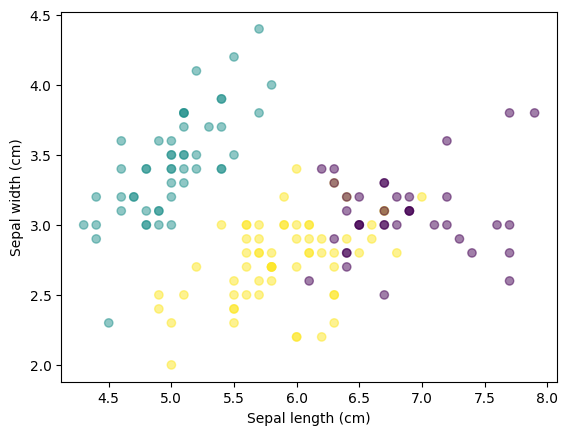

In [14]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, n_init=10)
model.fit(samples)
model.predict(samples)

labels = model.predict(samples)
print(labels)

plt.scatter(x, y, c=labels, alpha=0.5)
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')

In [12]:
new_samples = np.array([[5.7, 4.4, 1.5, 0.4],
   [6.5, 3. , 5.5, 0.4],
   [5.8, 2.7, 5.1, 1.9]])

model.predict(new_samples)
print(model.predict(new_samples))

new_names = [iris.target_names[label] for label in labels]
print(new_names)

[1 2 2]
['versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'virginica', 'virginica', 'setosa', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virgini

<h1>Model Evaluation</h1>

In [17]:
target = iris.target
species = [iris.target_names[t] for t in list(target)]
df = pd.DataFrame({'labels': labels, 'species': species})
print(df)

ct = pd.crosstab(df['labels'], df['species'])
display(ct)

     labels    species
0         1     setosa
1         1     setosa
2         1     setosa
3         1     setosa
4         1     setosa
..      ...        ...
145       0  virginica
146       2  virginica
147       0  virginica
148       0  virginica
149       2  virginica

[150 rows x 2 columns]


species,setosa,versicolor,virginica
labels,,,
0,0,2,36
1,50,0,0
2,0,48,14


<h1>Finding optimal K</h1>

Done using model.inertia_ which returns a metric describing how tight the clusters are

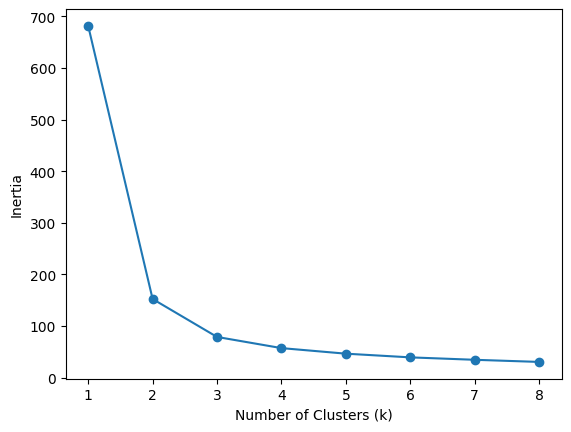

In [19]:
num_clusters = list(range(1,9))
inertias=[]

for cluster in num_clusters:
  model = KMeans(cluster, n_init=10)
  model.fit(samples)
  inertias.append(model.inertia_)

plt.plot(num_clusters, inertias, '-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()